<a href="https://colab.research.google.com/github/mtalhak003/AI-ML-Deep-Learning/blob/main/Training_and_Evaluation_of_AI_Models_for_Flood_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy scikit-learn tensorflow matplotlib openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [4]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name, header=None)

print(df.head())

Saving Annual Peak Discharge.xlsx to Annual Peak Discharge.xlsx
   0   1   2       3    4   5   6                               7    8   9   \
0 NaN NaN NaN     NaN  NaN NaN NaN                             NaN  NaN NaN   
1 NaN NaN NaN     NaN  NaN NaN NaN  Annual Peak Discharge (cumecs)  NaN NaN   
2 NaN NaN NaN     NaN  NaN NaN NaN                             NaN  NaN NaN   
3 NaN NaN NaN     NaN  NaN NaN NaN                             NaN  NaN NaN   
4 NaN NaN NaN  Warsak  NaN NaN NaN                        Chakdara  NaN NaN   

   10        11   12  
0 NaN       NaN  NaN  
1 NaN       NaN  NaN  
2 NaN       NaN  NaN  
3 NaN       NaN  NaN  
4 NaN  Nowshera  NaN  


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [7]:
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name, header=None)

print(df.head(10))

   0   1   2       3          4   5   6                               7   \
0 NaN NaN NaN     NaN        NaN NaN NaN                             NaN   
1 NaN NaN NaN     NaN        NaN NaN NaN  Annual Peak Discharge (cumecs)   
2 NaN NaN NaN     NaN        NaN NaN NaN                             NaN   
3 NaN NaN NaN     NaN        NaN NaN NaN                             NaN   
4 NaN NaN NaN  Warsak        NaN NaN NaN                        Chakdara   
5 NaN NaN NaN    Year  Discharge NaN NaN                            Year   
6 NaN NaN NaN    1965       2921 NaN NaN                            1961   
7 NaN NaN NaN    1966       3125 NaN NaN                            1962   
8 NaN NaN NaN    1967     2983.9 NaN NaN                            1963   
9 NaN NaN NaN    1968     2685.3 NaN NaN                            1964   

          8   9   10        11         12  
0        NaN NaN NaN       NaN        NaN  
1        NaN NaN NaN       NaN        NaN  
2        NaN NaN NaN       NaN 

In [8]:
warsak = df.iloc[6:, [3, 4]]
warsak.columns = ["Year", "Discharge"]
warsak["Station"] = "Warsak"

chakdara = df.iloc[6:, [7, 8]]
chakdara.columns = ["Year", "Discharge"]
chakdara["Station"] = "Chakdara"

nowshera = df.iloc[6:, [11, 12]]
nowshera.columns = ["Year", "Discharge"]
nowshera["Station"] = "Nowshera"

data = pd.concat([warsak, chakdara, nowshera], ignore_index=True)

data["Year"] = pd.to_numeric(data["Year"], errors="coerce")
data["Discharge"] = pd.to_numeric(data["Discharge"], errors="coerce")

data = data.dropna()

print(data.head())

     Year  Discharge Station
0  1965.0     2921.0  Warsak
1  1966.0     3125.0  Warsak
2  1967.0     2983.9  Warsak
3  1968.0     2685.3  Warsak
4  1969.0     2172.1  Warsak


In [9]:
station_name = "Nowshera"

In [10]:
station_name = "Warsak"

In [11]:
station_name = "Chakdara"

In [12]:

station_data = data[data["Station"] == station_name].copy()

station_data = station_data.sort_values("Year")

print(station_data)

       Year  Discharge   Station
55   1961.0      677.0  Chakdara
56   1962.0      917.0  Chakdara
57   1963.0      580.0  Chakdara
58   1964.0      722.0  Chakdara
59   1965.0      719.0  Chakdara
60   1966.0      705.0  Chakdara
61   1967.0      750.0  Chakdara
62   1968.0      750.0  Chakdara
63   1969.0      773.0  Chakdara
64   1970.0      572.0  Chakdara
65   1971.0      490.0  Chakdara
66   1972.0      677.0  Chakdara
67   1973.0      574.0  Chakdara
68   1974.0      504.0  Chakdara
69   1975.0      864.0  Chakdara
70   1976.0      580.0  Chakdara
71   1977.0      731.0  Chakdara
72   1978.0      790.0  Chakdara
73   1979.0      566.0  Chakdara
74   1980.0      616.9  Chakdara
75   1981.0      702.0  Chakdara
76   1982.0      433.0  Chakdara
77   1983.0      498.0  Chakdara
78   1984.0      611.0  Chakdara
79   1985.0      719.0  Chakdara
80   1986.0      659.0  Chakdara
81   1987.0      574.0  Chakdara
82   1988.0     1601.8  Chakdara
83   1989.0      744.3  Chakdara
84   1990.

In [13]:
X = station_data[["Year"]].values

y = station_data[["Discharge"]].values

In [14]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)

y_scaled = scaler_y.fit_transform(y)

In [15]:
split_index = int(len(X_scaled) * 0.8)

X_train = X_scaled[:split_index]
X_test = X_scaled[split_index:]

y_train = y_scaled[:split_index]
y_test = y_scaled[split_index:]

In [16]:
ann = Sequential()

ann.add(Dense(64, activation='relu', input_shape=(1,)))

ann.add(Dense(32, activation='relu'))

ann.add(Dropout(0.1))

ann.add(Dense(16, activation='relu'))

ann.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
ann.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

In [18]:
history = ann.fit(
    X_train,
    y_train,
    epochs=300,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.1158 - val_loss: 0.0824
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0858 - val_loss: 0.0368
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0550 - val_loss: 0.0171
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0426 - val_loss: 0.0136
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0360 - val_loss: 0.0230
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0353 - val_loss: 0.0344
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0333 - val_loss: 0.0418
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0356 - val_loss: 0.0442
Epoch 9/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0292 - val_loss: 0.0484
Epoch 10/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0349 - val_loss: 0.0447
Epoch 11/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0313 - val_loss: 0.0380
Epoch 12/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0341 - val_lo

In [19]:
ann_pred_scaled = ann.predict(X_test)

ann_pred = scaler_y.inverse_transform(ann_pred_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


In [20]:
svm = SVR(
    kernel='rbf',
    C=100,
    gamma=0.1,
    epsilon=0.01
)

svm.fit(X_train, y_train.ravel())

SVR(C=100, epsilon=0.01, gamma=0.1)

In [21]:
svm_pred_scaled = svm.predict(X_test)

svm_pred = scaler_y.inverse_transform(
    svm_pred_scaled.reshape(-1,1)
)

In [22]:
knn = KNeighborsRegressor(n_neighbors=3)

knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=3)

In [23]:
knn_pred_scaled = knn.predict(X_test)

knn_pred = scaler_y.inverse_transform(knn_pred_scaled)

In [24]:
y_actual = scaler_y.inverse_transform(y_test)

In [25]:
def evaluate_model(name, actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    mse = mean_squared_error(actual, predicted)

    rmse = np.sqrt(mse)

    r2 = r2_score(actual, predicted)

    mape = np.mean(
        np.abs((actual - predicted) / actual)
    ) * 100

    print("\n", name, "RESULTS")

    print("MAE  :", mae)

    print("MSE  :", mse)

    print("RMSE :", rmse)

    print("MAPE :", mape, "%")

    print("R2   :", r2)

In [26]:
evaluate_model("ANN", y_actual, ann_pred)

evaluate_model("SVM", y_actual, svm_pred)

evaluate_model("KNN", y_actual, knn_pred)


 ANN RESULTS
MAE  : 1214.038516512784
MSE  : 1553670.6782895639
RMSE : 1246.4632679263211
MAPE : 190.9870903992289 %
R2   : -47.57165868538971

 SVM RESULTS
MAE  : 194.80858515946983
MSE  : 58259.81981104079
RMSE : 241.37071034208105
MAPE : 34.143030313597606 %
R2   : -0.8213487082407189

 KNN RESULTS
MAE  : 158.0030303030303
MSE  : 32411.42111111111
RMSE : 180.0317225133146
MAPE : 25.003965504101956 %
R2   : -0.013262659658637821


In [27]:
results = pd.DataFrame({

    "Year": station_data["Year"].values[split_index:],

    "Actual": y_actual.flatten(),

    "ANN Prediction": ann_pred.flatten(),

    "SVM Prediction": svm_pred.flatten(),

    "KNN Prediction": knn_pred.flatten()
})

print(results)

      Year  Actual  ANN Prediction  SVM Prediction  KNN Prediction
0   2005.0   913.6     1729.243408      807.488388      739.333333
1   2006.0   982.2     1769.949585      815.918942      739.333333
2   2007.0   844.2     1810.656128      824.602140      739.333333
3   2008.0   728.5     1851.362183      833.534831      739.333333
4   2009.0   695.3     1892.068726      842.713781      739.333333
5   2010.0   791.4     1932.774902      852.135682      739.333333
6   2011.0   467.3     1973.481201      861.797153      739.333333
7   2012.0   529.1     2014.187256      871.694738      739.333333
8   2013.0   921.0     2054.893799      881.824910      739.333333
9   2014.0   493.1     2095.600098      892.184072      739.333333
10  2015.0   540.4     2136.306396      902.768560      739.333333


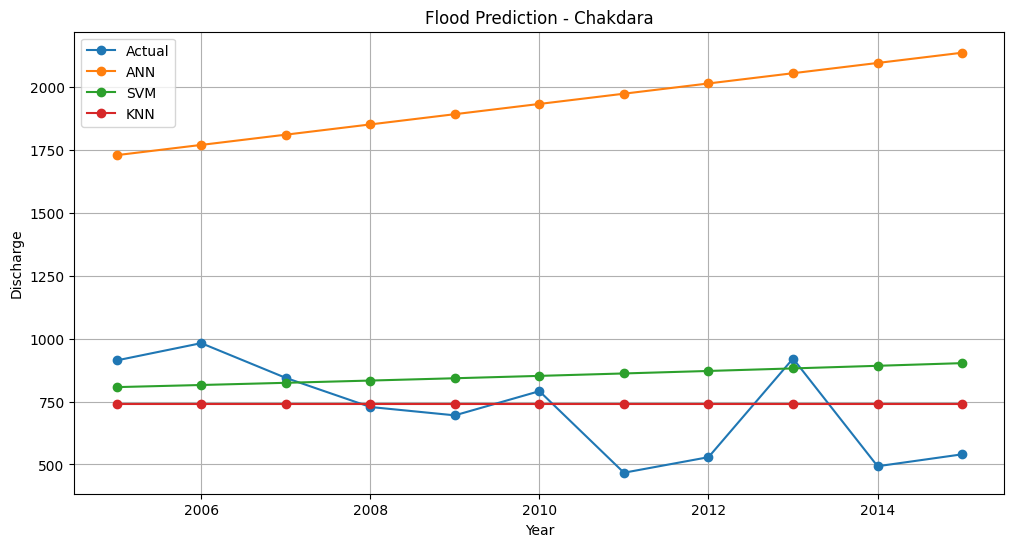

In [28]:
plt.figure(figsize=(12,6))

plt.plot(
    results["Year"],
    results["Actual"],
    marker='o',
    label='Actual'
)

plt.plot(
    results["Year"],
    results["ANN Prediction"],
    marker='o',
    label='ANN'
)

plt.plot(
    results["Year"],
    results["SVM Prediction"],
    marker='o',
    label='SVM'
)

plt.plot(
    results["Year"],
    results["KNN Prediction"],
    marker='o',
    label='KNN'
)

plt.xlabel("Year")

plt.ylabel("Discharge")

plt.title(f"Flood Prediction - {station_name}")

plt.legend()

plt.grid(True)

plt.show()

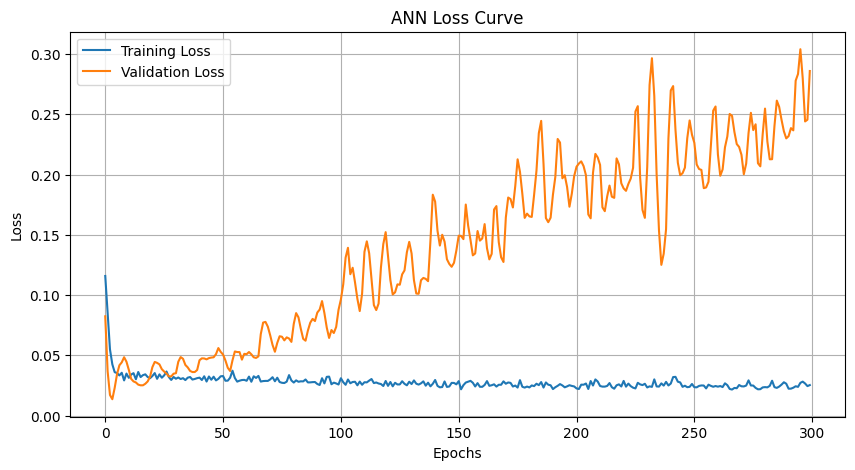

In [29]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("ANN Loss Curve")

plt.legend()

plt.grid(True)

plt.show()

In [30]:
future_years = np.array([
    [2026],
    [2027],
    [2028],
    [2029],
    [2030]
])

In [31]:
future_scaled = scaler_X.transform(future_years)

future_ann = scaler_y.inverse_transform(
    ann.predict(future_scaled)
)

future_svm = scaler_y.inverse_transform(
    svm.predict(future_scaled).reshape(-1,1)
)

future_knn = scaler_y.inverse_transform(
    knn.predict(future_scaled)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


In [32]:
future_results = pd.DataFrame({

    "Year": future_years.flatten(),

    "ANN Prediction": future_ann.flatten(),

    "SVM Prediction": future_svm.flatten(),

    "KNN Prediction": future_knn.flatten()
})

print(future_results)

   Year  ANN Prediction  SVM Prediction  KNN Prediction
0  2026     2583.634521     1032.958731      739.333333
1  2027     2624.291016     1045.939021      739.333333
2  2028     2664.916992     1059.091643      739.333333
3  2029     2705.479492     1072.412173      739.333333
4  2030     2746.042969     1085.896152      739.333333
